In [6]:
# Temel veri analizi, görselleştirme ve makine öğrenmesi kütüphaneleri yükleniyor
import json
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import statsmodels.api as sm

# Görselleştirme stilleri ve uyarıların kapatılması
sns.set_style("whitegrid")
sns.set_context("notebook")
warnings.filterwarnings("ignore")

In [7]:
# CSV dosyasını noktalı virgül (sep=';') ayracı ile okuyup ilk iki satırı görüntülüyoruz
csv_path = "/content/sample_data/student-por.csv"
df = pd.read_csv(csv_path, sep=";")
df.head(2)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11


In [8]:
# Veri boyutunu, sütun tiplerini yazdırıp eksik veri varsa uygun yöntemle dolduruyoruz
print("Veri Seti Boyutu:", df.shape)
df.info()

# Eksik değerleri kontrol ediyoruz
print("\nEksik Veri Sayıları:\n", df.isnull().sum())

# Sayısal sütunlardaki olası boşlukları medyan, kategorikleri en sık geçen (mod) değer ile dolduruyoruz
for col in df.columns:
  if df[col].isnull().sum() > 0:
    if df[col].dtype in ["float64", "int64"]:
      df[col] = df[col].fillna(df[col].median())
    else:
      df[col] = df[col].fillna(df[col].mode()[0])

print("Eksik veri kontrolü tamamlandı, kalan boş değer:", df.isnull().sum().sum())

Veri Seti Boyutu: (649, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-nu

In [ ]:
# Sayısal sütunların ortalama, standart sapma, min-max çeyreklik özet tablosunu çıkarıyoruz
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [9]:
# 'sex' sütunundaki öğrencilerin cinsiyet frekanslarını inceliyoruz
df["sex"].value_counts()

,count
sex,
F,383
M,266


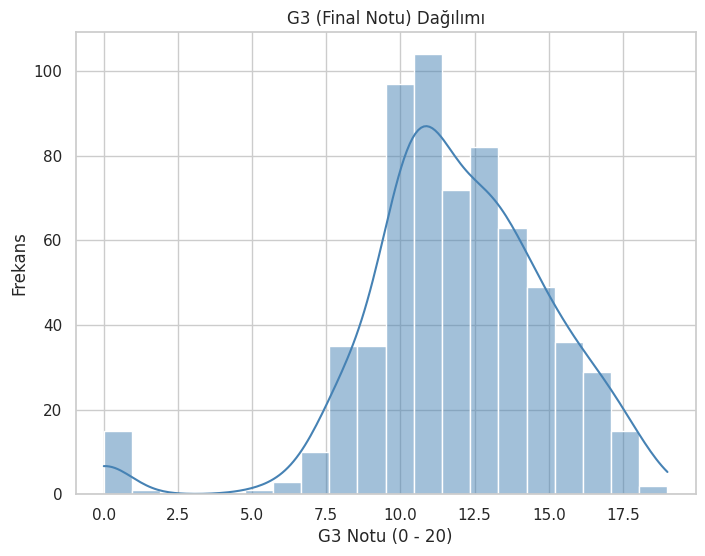

In [ ]:
# Tahmin edeceğimiz hedef değişken olan final notunun (G3) histogram ve yoğunluk eğrisini çizdiriyoruz
plt.figure(figsize=(8, 6))
sns.histplot(df["G3"], bins=20, kde=True, color="steelblue")
plt.title("G3 (Final Notu) Dağılımı")
plt.xlabel("G3 Notu (0 - 20)")
plt.ylabel("Frekans")
plt.show()

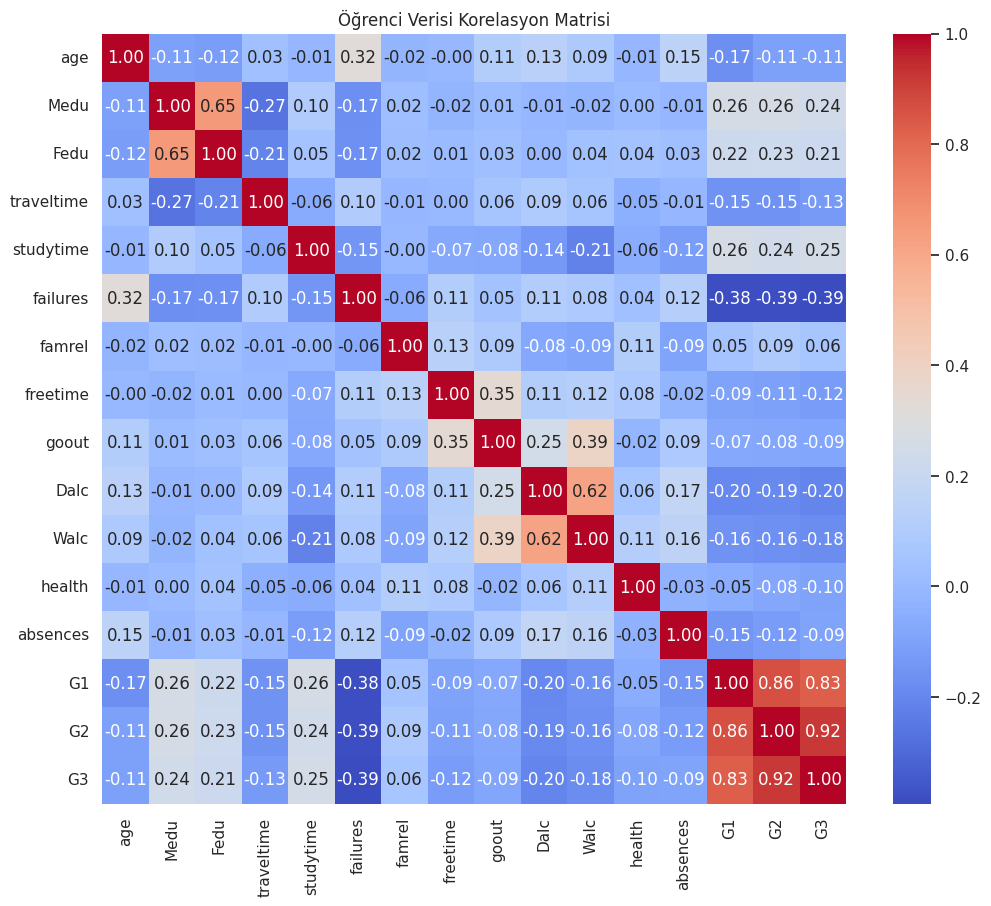

In [ ]:
# Sayısal sütunlar arasındaki korelasyon katsayılarını hesaplayıp ısı haritası üzerinde görselleştiriyoruz
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Öğrenci Verisi Korelasyon Matrisi")
plt.show()

In [11]:
# Metin içeren tüm kategorik sütunları kukla (dummy) değişkenlere çevirip 0 ve 1 değerlerine dönüştürüyoruz
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

bool_cols = df_encoded.select_dtypes(include="bool").columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

df_encoded.head(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0


In [13]:
# Girdi özniteliklerini (X) ve hedef değişken olan final notunu (y = G3) belirliyoruz
X = df_encoded.drop(columns=["G3"])
y = df_encoded["G3"]

In [14]:
# Veriyi %80 eğitim ve %20 test olacak biçimde bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Doğrusal regresyon modelini eğitip test verisi üzerinde tahminler üretiyoruz
model = LinearRegression()
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

In [20]:
# Test verisi üzerinden R-kare, MAE, MSE ve RMSE hata metriklerini hesaplayıp yazdırıyoruz
r2_multi = r2_score(y_test, model_pred)
mae_multi = mean_absolute_error(y_test, model_pred)
mse_multi = mean_squared_error(y_test, model_pred)
rmse_multi = np.sqrt(mse_multi)

print("R2 Değeri  :", r2_multi)
print("MAE Değeri :", mae_multi)
print("MSE Değeri :", mse_multi)
print("RMSE Değeri:", rmse_multi)

R2 Değeri  : 0.8486513286537316
MAE Değeri : 0.7650597682758257
MSE Değeri : 1.4759092563639304
RMSE Değeri: 1.2148700573987041


In [21]:
# Katsayıların anlamlılığı ve p-değerlerini görmek için OLS regresyon özetini çıkarıyoruz
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                     G3   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     70.49
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          1.86e-175
Time:                        06:56:58   Log-Likelihood:                -840.11
No. Observations:                 519   AIC:                             1764.
Df Residuals:                     477   BIC:                             1943.
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.9519      1.11

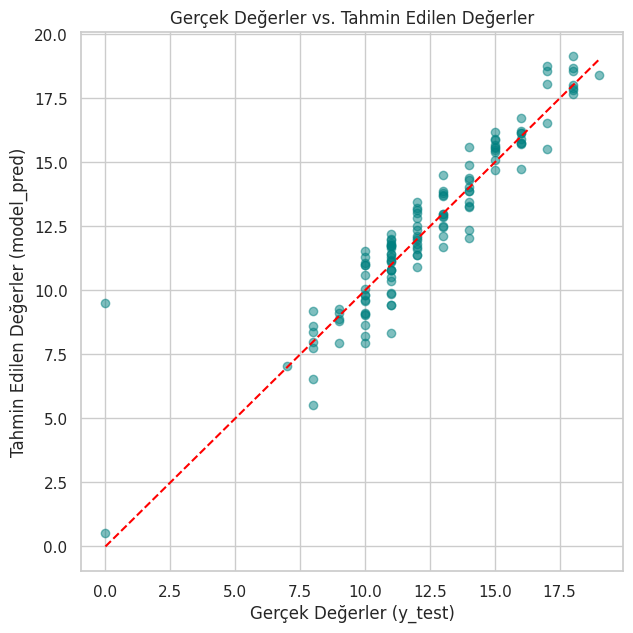

In [22]:
# Model tahminleri ile gerçek değerlerin karşılaştırma saçılım grafiğini çizdiriyoruz
plt.figure(figsize=(7, 7))
plt.scatter(y_test, model_pred, alpha=0.5, color="teal")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Gerçek Değerler (y_test)")
plt.ylabel("Tahmin Edilen Değerler (model_pred)")
plt.title("Gerçek Değerler vs. Tahmin Edilen Değerler")
plt.show()

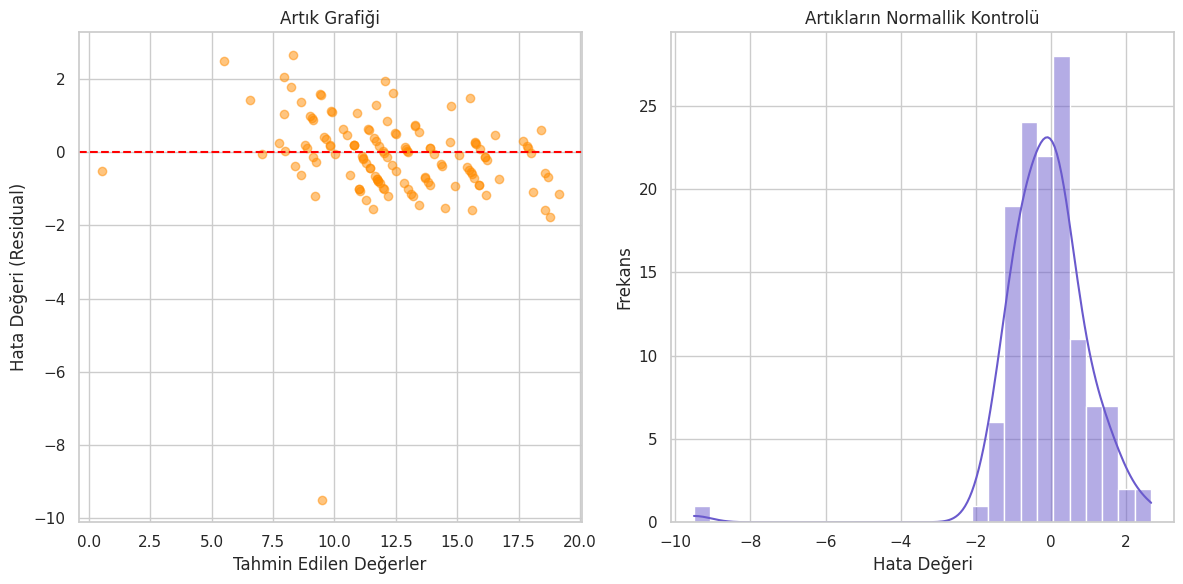

In [23]:
# Hata artıklarının sıfır ekseni etrafındaki dağılımını ve histogramını çizdiriyoruz
residual = y_test - model_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(model_pred, residual, alpha=0.5, color="darkorange")
axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_xlabel("Tahmin Edilen Değerler")
axes[0].set_ylabel("Hata Değeri (Residual)")
axes[0].set_title("Artık Grafiği")

sns.histplot(residual, kde=True, ax=axes[1], color="slateblue")
axes[1].set_title("Artıkların Normallik Kontrolü")
axes[1].set_xlabel("Hata Değeri")
axes[1].set_ylabel("Frekans")

plt.tight_layout()
plt.show()

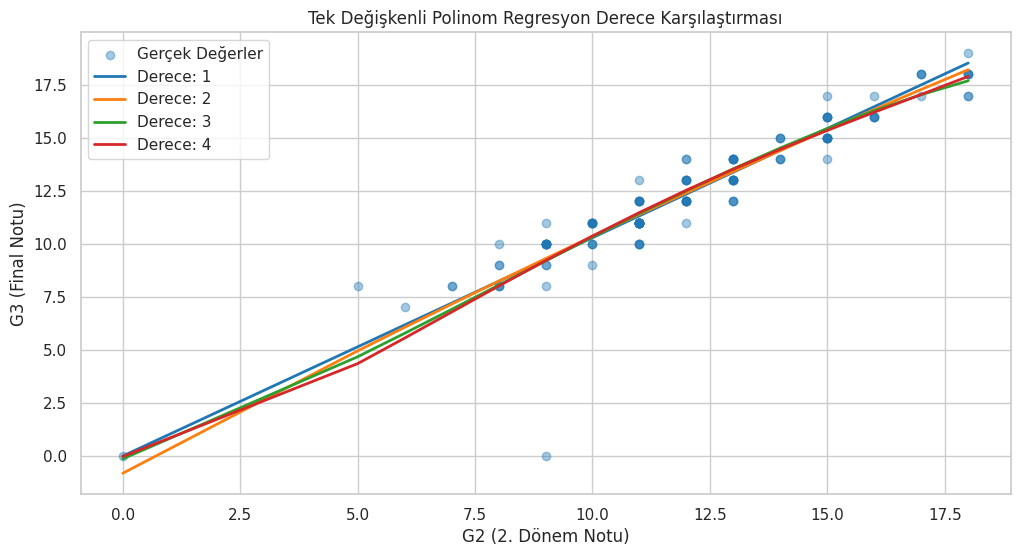

,r2,Rmse
Derece,,
1,0.868809,1.131080
2,0.868176,1.133805
3,0.863961,1.151788
4,0.860773,1.165205


In [24]:
# En yüksek korelasyona sahip G2 (2. dönem notu) üzerinden 1'den 4'e kadar dereceleri kıyaslıyoruz
degrees = [1, 2, 3, 4]
poly_results = {}

plt.figure(figsize=(12, 6))
X_one_train = X_train[["G2"]]
X_one_test = X_test[["G2"]]
sort_idx = X_one_test["G2"].values.argsort()
x_sorted = X_one_test["G2"].values[sort_idx]

plt.scatter(
    X_one_test["G2"],
    y_test,
    alpha=0.4,
    color="#1f77b4",
    label="Gerçek Değerler",
)

for degree in degrees:
  model_poly = make_pipeline(PolynomialFeatures(degree), LinearRegression())
  model_poly.fit(X_one_train, y_train)
  poly_pred = model_poly.predict(X_one_test)
  poly_results[degree] = {
      "r2": r2_score(y_test, poly_pred),
      "Rmse": np.sqrt(mean_squared_error(y_test, poly_pred)),
  }
  y_line = model_poly.predict(x_sorted.reshape(-1, 1))
  plt.plot(x_sorted, y_line, linewidth=2, label=f"Derece: {degree}")

plt.xlabel("G2 (2. Dönem Notu)")
plt.ylabel("G3 (Final Notu)")
plt.title("Tek Değişkenli Polinom Regresyon Derece Karşılaştırması")
plt.legend()
plt.show()

pd.DataFrame(poly_results).T.rename_axis("Derece")

In [25]:
# 2. dereceden çok değişkenli polinom özellikler türeterek regresyon modelini eğitiyoruz
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly_features.fit_transform(X_train)
X_poly_test = poly_features.transform(X_test)

poly_multi_model = LinearRegression()
poly_multi_model.fit(X_poly_train, y_train)
poly_multi_pred = poly_multi_model.predict(X_poly_test)

r2_score_poly = r2_score(y_test, poly_multi_pred)
mae_poly = mean_absolute_error(y_test, poly_multi_pred)
rmse_poly = np.sqrt(mean_squared_error(y_test, poly_multi_pred))

print("Çok Değişkenli Polinom R2 Değeri :", r2_score_poly)
print("Çok Değişkenli Polinom MAE Değeri:", mae_poly)
print("Çok Değişkenli Polinom RMSE Değeri:", rmse_poly)

Çok Değişkenli Polinom R2 Değeri : 0.13360909550778566
Çok Değişkenli Polinom MAE Değeri: 2.0222393453112923
Çok Değişkenli Polinom RMSE Değeri: 2.9066816174264605


In [26]:
# Not defterinizdeki Bad_risk mantığına uygun olarak 10 ve üzeri alanları Geçti (1), altını Kaldı (0) yapıyoruz
df["Passed"] = (df["G3"] >= 10).astype(int)
df["Passed"].value_counts(normalize=True).rename(
    index={0: "Kaldı (0)", 1: "Geçti (1)"}
)

,proportion
Passed,
Geçti (1),0.845917
Kaldı (0),0.154083


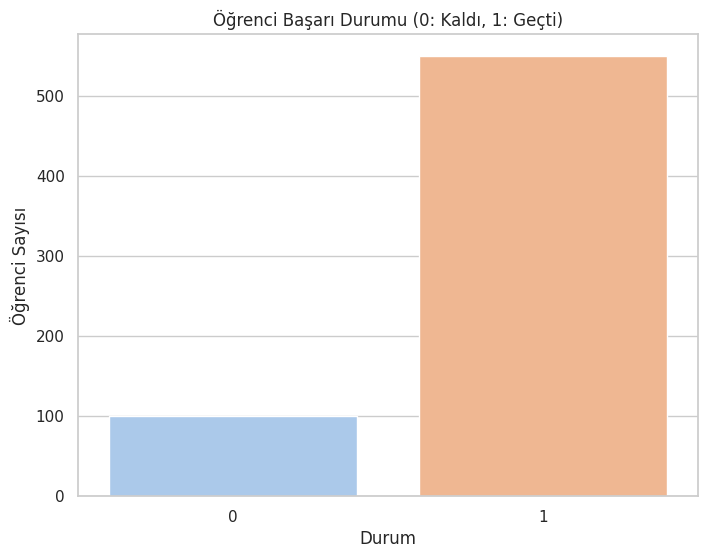

In [27]:
# Geçen ve kalan öğrencilerin sayısal dengesini gösteren sütun grafiğini çizdiriyoruz
plt.figure(figsize=(8, 6))
sns.countplot(x="Passed", data=df, palette="pastel")
plt.title("Öğrenci Başarı Durumu (0: Kaldı, 1: Geçti)")
plt.xlabel("Durum")
plt.ylabel("Öğrenci Sayısı")
plt.show()

In [28]:
# Hedef değişken Passed olup veri sızıntısını önlemek için G3 çıkarılır ve sınıf orantılı ayrılır
df_clf_encoded = pd.get_dummies(
    df.drop(columns=["G3"]), columns=categorical_cols, drop_first=True
)
bool_cols = df_clf_encoded.select_dtypes(include="bool").columns.tolist()
df_clf_encoded[bool_cols] = df_clf_encoded[bool_cols].astype(int)

X_clf = df_clf_encoded.drop(columns=["Passed"])
y_clf = df_clf_encoded["Passed"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

In [29]:
# Lojistik regresyonun daha kararlı çalışması için özellikleri ölçeklendiriyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)
X_test_scaled = scaler.transform(X_test_c)

X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X_clf.columns, index=X_train_c.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=X_clf.columns, index=X_test_c.index
)
X_train_scaled.head(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
151,-0.591052,1.315936,1.535526,-0.731477,1.26341,-0.37338,1.122563,-0.157555,-0.146579,-0.5371,...,0.667595,-0.26477,-0.358135,0.788591,-0.260579,1.005797,0.479435,0.337245,0.566225,-0.750502
235,0.211974,-1.321017,-1.162910,-0.731477,1.26341,-0.37338,0.095032,-0.157555,0.698695,-0.5371,...,0.667595,-0.26477,-0.358135,0.788591,-0.260579,1.005797,0.479435,0.337245,-1.766083,1.332442


In [30]:
# Lojistik regresyon modelini eğitip katsayıları optimize ediyoruz
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train_c)

LogisticRegression(max_iter=1000)

In [31]:
# İlk 10 test örneği için gerçek sınıf, tahmin edilen sınıf ve geçme olasılığını listeliyoruz
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred_c = log_reg.predict(X_test_scaled)

results_preview = pd.DataFrame({
    "Gerçek:": y_test_c.values[:10],
    "Tahmin:": y_pred_c[:10],
    "Olasılık:": y_proba[:10].round(2),
})
results_preview

,Gerçek:,Tahmin:,Olasılık:
0,1,1,1.00
1,1,1,0.99
2,1,1,1.00
3,1,1,1.00
4,1,0,0.27
5,0,0,0.01
6,0,0,0.40
7,1,1,1.00
8,1,1,1.00
9,1,1,0.96


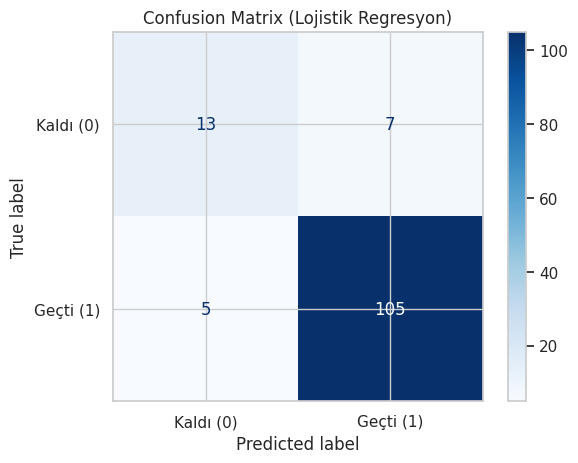

In [32]:
# Doğru ve yanlış tahminleri gösteren karmaşıklık matrisini çizdiriyoruz
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Kaldı (0)", "Geçti (1)"]
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Lojistik Regresyon)")
plt.show()

In [33]:
# Doğruluk, kesinlik, duyarlılık, F1 puanı ve detaylı sınıflandırma raporunu yazdırıyoruz
accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}\n")

print(classification_report(y_test_c, y_pred_c))

Accuracy : 0.9077
Precision: 0.9375
Recall   : 0.9545
F1 Score : 0.9459

              precision    recall  f1-score   support

           0       0.72      0.65      0.68        20
           1       0.94      0.95      0.95       110

    accuracy                           0.91       130
   macro avg       0.83      0.80      0.82       130
weighted avg       0.90      0.91      0.91       130



In [34]:
# Doğrusal (Linear) SVM Eğitimi ve Değerlendirmesi
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

# 1. Doğrusal Çekirdekli SVM Modeli
svm_linear = SVC(kernel="linear", C=1.0, probability=True, random_state=42)
svm_linear.fit(X_train_scaled, y_train_c)

y_pred_linear = svm_linear.predict(X_test_scaled)
y_proba_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

print(f"Toplam Destek Vektörü Sayısı: {svm_linear.n_support_.sum()}")
print(f"Destek Vektörleri Matris Boyutu: {svm_linear.support_vectors_.shape}")

# Metriklerin hesaplanması
acc_svm = accuracy_score(y_test_c, y_pred_linear)
prec_svm = precision_score(y_test_c, y_pred_linear)
rec_svm = recall_score(y_test_c, y_pred_linear)
f1_svm = f1_score(y_test_c, y_pred_linear)

print("\n--- Linear SVM Sonuçları ---")
print(f"Accuracy : {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall   : {rec_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}\n")
print(classification_report(y_test_c, y_pred_linear, target_names=["Kaldı (0)", "Geçti (1)"]))

Toplam Destek Vektörü Sayısı: 78
Destek Vektörleri Matris Boyutu: (78, 41)

--- Linear SVM Sonuçları ---
Accuracy : 0.9077
Precision: 0.9455
Recall   : 0.9455
F1 Score : 0.9455

              precision    recall  f1-score   support

   Kaldı (0)       0.70      0.70      0.70        20
   Geçti (1)       0.95      0.95      0.95       110

    accuracy                           0.91       130
   macro avg       0.82      0.82      0.82       130
weighted avg       0.91      0.91      0.91       130



In [35]:
# 2. RBF (Radial Basis Function) Çekirdekli SVM
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train_c)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

acc_svm_rbf = accuracy_score(y_test_c, y_pred_rbf)
prec_svm_rbf = precision_score(y_test_c, y_pred_rbf)
rec_svm_rbf = recall_score(y_test_c, y_pred_rbf)
f1_svm_rbf = f1_score(y_test_c, y_pred_rbf)
auc_svm_rbf = roc_auc_score(y_test_c, y_proba_rbf)

print("--- SVM (RBF Çekirdek) Sonuçları ---")
print(f"Accuracy : {acc_svm_rbf:.4f}")
print(f"Precision: {prec_svm_rbf:.4f}")
print(f"Recall   : {rec_svm_rbf:.4f}")
print(f"F1 Score : {f1_svm_rbf:.4f}")
print(f"AUC      : {auc_svm_rbf:.4f}")

--- SVM (RBF Çekirdek) Sonuçları ---
Accuracy : 0.8692
Precision: 0.8908
Recall   : 0.9636
F1 Score : 0.9258
AUC      : 0.8764


In [36]:
# GridSearchCV ile SVM Hiperparametre Optimizasyonu
from sklearn.model_selection import GridSearchCV

param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": [1, 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}

grid_search_svm = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svm, cv=5, scoring="f1", n_jobs=-1)
grid_search_svm.fit(X_train_scaled, y_train_c)

print("En İyi SVM Parametreleri:", grid_search_svm.best_params_)
print(f"En İyi Çapraz Doğrulama F1 Skoru: {grid_search_svm.best_score_:.4f}")

# En iyi modelin test seti performansı
svm_best = grid_search_svm.best_estimator_
y_pred_best_svm = svm_best.predict(X_test_scaled)
y_proba_best_svm = svm_best.predict_proba(X_test_scaled)[:, 1]

acc_svm_best = accuracy_score(y_test_c, y_pred_best_svm)
prec_svm_best = precision_score(y_test_c, y_pred_best_svm)
rec_svm_best = recall_score(y_test_c, y_pred_best_svm)
f1_svm_best = f1_score(y_test_c, y_pred_best_svm)
auc_svm_best = roc_auc_score(y_test_c, y_proba_best_svm)

print("\n--- Optimize Edilmiş SVM Test Sonuçları ---")
print(f"Accuracy : {acc_svm_best:.4f}")
print(f"Precision: {prec_svm_best:.4f}")
print(f"Recall   : {rec_svm_best:.4f}")
print(f"F1 Score : {f1_svm_best:.4f}")
print(f"AUC      : {auc_svm_best:.4f}")

En İyi SVM Parametreleri: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
En İyi Çapraz Doğrulama F1 Skoru: 0.9530

--- Optimize Edilmiş SVM Test Sonuçları ---
Accuracy : 0.9000
Precision: 0.9450
Recall   : 0.9364
F1 Score : 0.9406
AUC      : 0.9232


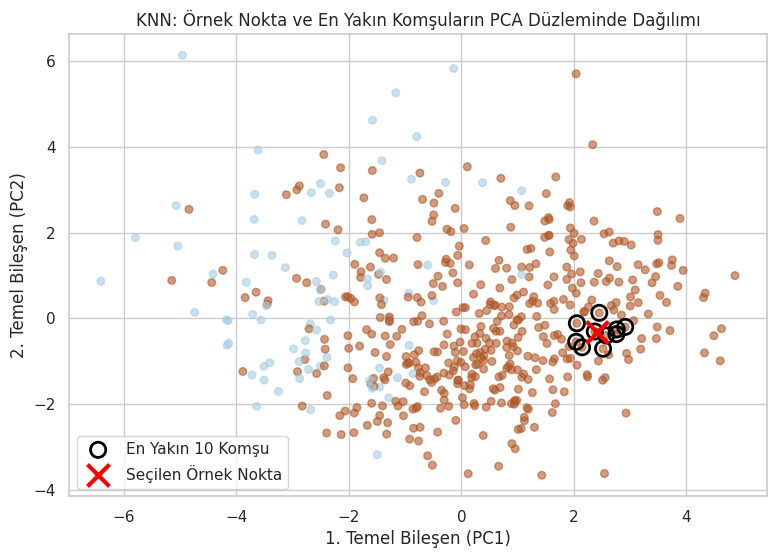

In [37]:
# PCA ile Boyut İndirgeme ve Örnek Noktanın Komşularını Görselleştirme
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# 1. PCA ile 2 ana bileşene indirgeme
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# 2. Rastgele bir örnek nokta seçip en yakın k komşusunu bulma
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_pca))
sample_point = X_train_pca[sample_idx]

distances = np.sqrt(((X_train_pca - sample_point) ** 2).sum(axis=1))
k_example = 10
nearest_neighbors = distances.argsort()[1:k_example + 1]

# 3. Görselleştirme
plt.figure(figsize=(9, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_c, cmap=plt.cm.Paired, alpha=0.6, s=30)
plt.scatter(X_train_pca[nearest_neighbors, 0], X_train_pca[nearest_neighbors, 1], facecolors='none', edgecolors='black', s=120, linewidths=2, label="En Yakın 10 Komşu")
plt.scatter(sample_point[0], sample_point[1], c="red", marker="x", s=250, linewidths=3, label="Seçilen Örnek Nokta")

plt.title("KNN: Örnek Nokta ve En Yakın Komşuların PCA Düzleminde Dağılımı")
plt.xlabel("1. Temel Bileşen (PC1)")
plt.ylabel("2. Temel Bileşen (PC2)")
plt.legend()
plt.show()

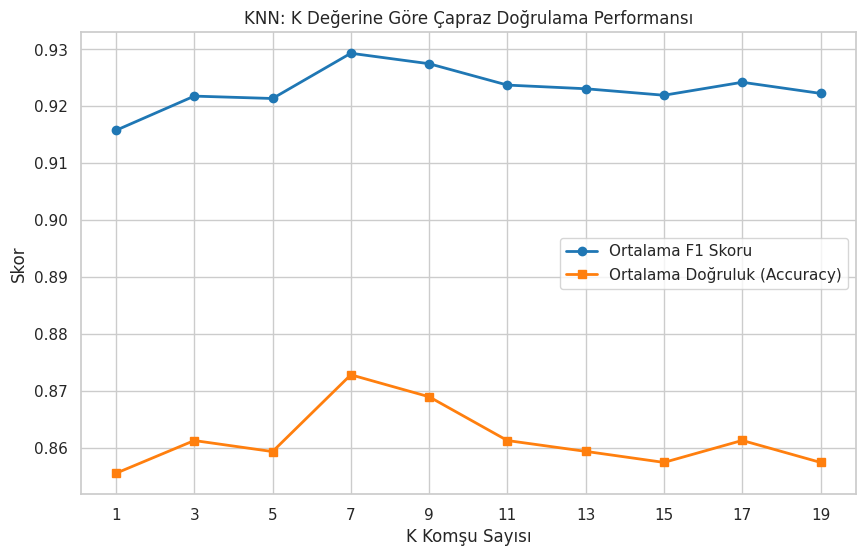

In [38]:
# Farklı $K$ Değerleri için 5 Katlı Çapraz Doğrulama Eğrisi (Elbow Mantığı)
from sklearn.model_selection import cross_val_score

k_values = list(range(1, 21, 2))
cv_f1_scores = []
cv_accuracy_scores = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    f1_scores = cross_val_score(knn_model, X_train_scaled, y_train_c, cv=5, scoring="f1")
    accuracy_scores = cross_val_score(knn_model, X_train_scaled, y_train_c, cv=5, scoring="accuracy")

    cv_f1_scores.append(np.mean(f1_scores))
    cv_accuracy_scores.append(np.mean(accuracy_scores))

plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_f1_scores, marker="o", linewidth=2, label="Ortalama F1 Skoru")
plt.plot(k_values, cv_accuracy_scores, marker="s", linewidth=2, label="Ortalama Doğruluk (Accuracy)")
plt.title("KNN: K Değerine Göre Çapraz Doğrulama Performansı")
plt.xlabel("K Komşu Sayısı")
plt.ylabel("Skor")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

En İyi KNN Parametreleri: {'n_neighbors': 7, 'p': 2, 'weights': 'distance'}
En İyi Çapraz Doğrulama F1 Skoru: 0.9313

--- Optimize Edilmiş KNN Test Sonuçları ---
Accuracy : 0.8308
Precision: 0.8548
Recall   : 0.9636
F1 Score : 0.9060
AUC      : 0.6859


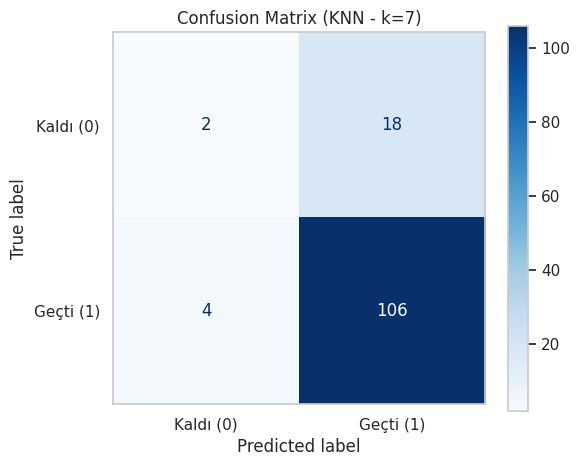

In [39]:
# GridSearchCV ile En Uygun KNN Hiperparametrelerinin Bulunması
param_grid_knn = {
    "n_neighbors": list(range(1, 21, 2)),
    "weights": ["uniform", "distance"],
    "p": [1, 2]  # 1: Manhattan, 2: Öklid mesafesi
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring="f1", n_jobs=-1)
grid_search_knn.fit(X_train_scaled, y_train_c)

print("En İyi KNN Parametreleri:", grid_search_knn.best_params_)
print(f"En İyi Çapraz Doğrulama F1 Skoru: {grid_search_knn.best_score_:.4f}")

# En iyi KNN modeli ile tahmin
knn_best = grid_search_knn.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)
y_proba_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

acc_knn = accuracy_score(y_test_c, y_pred_knn)
prec_knn = precision_score(y_test_c, y_pred_knn)
rec_knn = recall_score(y_test_c, y_pred_knn)
f1_knn = f1_score(y_test_c, y_pred_knn)
auc_knn = roc_auc_score(y_test_c, y_proba_knn)

print("\n--- Optimize Edilmiş KNN Test Sonuçları ---")
print(f"Accuracy : {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall   : {rec_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"AUC      : {auc_knn:.4f}")

# KNN Karışıklık Matrisi
cm_knn = confusion_matrix(y_test_c, y_pred_knn)
fig, ax = plt.subplots(figsize=(6, 5))
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Kaldı (0)", "Geçti (1)"])
disp_knn.plot(ax=ax, cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (KNN - k={grid_search_knn.best_params_['n_neighbors']})")
plt.grid(False)
plt.show()

In [40]:
# Tüm eğitilen modelleri tek bir özet tabloda toplayıp kıyaslayalım
comparison_df = pd.DataFrame({
    "Model": [
        "Lojistik Regresyon",
        "SVM (RBF - Optimize)",
        f"KNN (k={grid_search_knn.best_params_['n_neighbors']})"
    ],
    "Doğruluk (Accuracy)": [
        accuracy_score(y_test_c, y_pred_c),
        acc_svm_best,
        acc_knn
    ],
    "Kesinlik (Precision)": [
        precision_score(y_test_c, y_pred_c),
        prec_svm_best,
        prec_knn
    ],
    "Duyarlılık (Recall)": [
        recall_score(y_test_c, y_pred_c),
        rec_svm_best,
        rec_knn
    ],
    "F1 Skoru": [
        f1_score(y_test_c, y_pred_c),
        f1_svm_best,
        f1_knn
    ],
    "ROC-AUC": [
        roc_auc_score(y_test_c, y_proba),
        auc_svm_best,
        auc_knn
    ]
})

display(comparison_df.round(4))

,Model,Doğruluk (Accuracy),Kesinlik (Precision),Duyarlılık (Recall),F1 Skoru,ROC-AUC
0,Lojistik Regresyon,0.9077,0.9375,0.9545,0.9459,0.9064
1,SVM (RBF - Optimize),0.9000,0.9450,0.9364,0.9406,0.9232
2,KNN (k=7),0.8308,0.8548,0.9636,0.9060,0.6859
